<style>
    pre {
        white-space: pre-wrap;
        word-wrap: break-word;
    }
</style>

<div style="display:flex; justify-content:space-around; align-items:center; background-color:#cccccc; padding:5px; border:2px solid #333333;">
    <a href="https://www.um.es/web/estudios/grados/ciencia-ingenieria-datos/" target="_blank">
    <img src="images/umu_logo.png" alt="UMU" style="height:200px; width:auto;">
    <a href="https://estudios.upct.es/grado/5251/inicio" target="_blank">
    <img src="images/upct_logo.png" alt="UPCT" style="height:145px; width:auto;">
</div>

# Asignatura: **Deep Learning**

## Titulación: **Grado en Ciencia e Ingeniería de Datos**

## Práctica 2: Redes Convolucionales
### **Sesión 2/3: La arquitectura U-Net**

**Autores**: Antonio Martínez Sánchez, Juan Morales Sánchez, José Luís Sancho Gómez y Juan Antonio Botía Blaya

<div style="page-break-before: always;"></div>

### Contenidos
- [Requisitos](#requisitos)
- [La arquitectura U-Net](#unet)
- [El dataset](#dataset)
- [Restauración de imágenes](#restauración)
- [Entrenamiento](#entrenamiento)
- [Ejercicios](#ejercicios)

### Requisitos
<a class='anchor' id='requisitos'></a>

Se trabajará con notebooks de [Jupyter](https://jupyter.org/install) con código Python empleando como intérprete la última versión de [Miniconda](https://docs.anaconda.com/miniconda/). Se requiere la preinstalación (se recomienda utilizar [pip](https://pypi.org/project/pip/)) de los siguientes paquetes de Python:

- [Numpy](https://pypi.org/project/numpy/) (computación numérica)
- [Scipy](https://pypi.org/project/scipy/) (computación científica)
- [Tensorflow](https://www.tensorflow.org/install/pip?hl=es-419#linux) que incluye a Keras (deep Learning)
- [Scikit-learn](https://pypi.org/project/scikit-learn/) (machine Learning)
- [Mrcfile](https://pypi.org/project/mrcfile/) (operationes E/S en ficheros MRC)
- [Matplotlib](https://pypi.org/project/matplotlib/) (visualización de datos)

Además, para la visualización 3D se recomienda la utilización de [Paraview](https://www.paraview.org/).

### La arquitectura U-Net
<a class='anchor' id='unet'></a>

Como hemos visto en el tema 2, cuando hablamos de segmentación, en algunas tareas de análisis de imagen es necesario trabajar a nivel de píxel en lugar de tomar una decisión, p.e.  clasificación, analizando el conjunto de la imagen. Para poder trabajar a este nivel, se requiere de una arquitectura encoder-decoder, de tal forma que primero un encoder analiza el contenido de la imagen y depués un decoder reconstruye la imagen resultante, la cual tendrá el mismo tamaño y estructura que la de entrada. 

Esta arquitectura se corresponde con la de un autoencoder, que se estudiará con detalle en la Práctica 4 y en el Tema 6 de Teoría. Los autoencoders trabajan de una forma muy característica, comprimiendo la imagen de entrada de forma progresiva hasta llegar al espacio latente deseado y, desde ahí, pasar a reconstruir la imagen original. Normalmente, como la información suele comprimirse demasiado, se hace después difícil para el decoder reconstruir la imagen con suficiente precisión. 

Para conseguir una reconstrucción con precisión a nivel de píxel en U-Net se introdujo una innovación, consistente en conectar capas homólogas en encoder y decoder de forma directa, las *skip connections*, y así el decoder puede realizar la tarea de reconstrucción de forma más efectiva, al suministrásele más información para la tarea. La arquitectura inicialmente propuesta se encuentra descrita aquí 

![Arquitectura U-Net para segmentación de imágenes médicas](images/unet_architecture.png)

Más información sobre esta red, incluyendo un video explicativo, disponible en la web de los autores [https://lmb.informatik.uni-freiburg.de/people/ronneber/u-net/](https://lmb.informatik.uni-freiburg.de/people/ronneber/u-net/).

En esta sesión de prácticas vamos a construir una red U-Net para restaurar imágenes altamente ruidosas de cryo-EM.

### El dataset
<a class='anchor' id='dataset'></a>

Se procesarán imágenes almacenadas en ficheros en formato [MRC](https://www.ccpem.ac.uk/mrc-format). Este formato soporta imágenes en 2D, 3D y secuencias de imágenes. Se llama así porque fue desarrollado por el MRC (Medical Research Council) del Reino Unido. 
Para leer este formato de almacenamiento se necesita el paquete *mrcfile*. 
Procedemos a instalarlo si no lo tenemos con 
```bash
pip install mrcfile
```

A modo de ejemplo sobre su uso se proporciona la siguiente función tomada del repositorio [PolNet](https://github.com/anmartinezs/polnet/blob/506309bb815d395131c97100272ce47b5c07d2d3/polnet/lio.py#L17C1-L32C20):

```python
import mrcfile

def load_mrc(fname, mmap=False, no_saxes=True):
    """
    Load an input MRC tomogram as ndarray

    :param fname: the input MRC
    :param mmap: if True (default False) the data are read as a memory map
    :param no_saxes: if True (default) then X and Y axes are swaped to cancel the swaping made by mrcfile package
    :return: a ndarray (or memmap is mmap=True)
    """
    if mmap:
        mrc = mrcfile.mmap(fname, permissive=True, mode='r+')
    else:
        mrc = mrcfile.open(fname, permissive=True, mode='r+')
    if no_saxes:
        return np.swapaxes(mrc.data, 0, 2)
    return mrc.data
```

El directorio con las imágenes es *images/SNR_low*, con un contenido similar al de la sesión anterior pero ahora las imágenes son mucho más ruidosas. El subdirectorio *noisy* contine las imágenes ruidosas y *clean* contiene la imágenes sin ruido, necesarias para poder realizar un aprendizaje supervisado.

El formato MRC se utiliza para almacenar tomografías y pilas de imágenes, esto es imágenes 3D generadas a partir de una secuencia de imágenes en 2D. En este caso, los archivos contienen una sola imagen 2D con diferentes tamaños. Antes de construir los tensores de entrada para la red, las imágenes se tienen que recortar para que todas tengan un tamaño 56x56 píxeles, es importante que se mantenga la parte central de la imagen durante el recorte. 

### Restauración de imágenes
<a class='anchor' id='restauracion'></a>

En esta sesión se resolverá el problema de la restauración de imágenes empleando una red U-Net. En algunos dominios de aplicación, como la microscopía electrónica, las imágenes sufren distorsiones y ruido introducidos por los sistemas de adquisición. La restauración, o filtrado de ruido, consiste en eliminar <u>en la medida de lo posible</u> estas distorsiones y ruido para recuperar una imagen que permita una mejor visualización del contenido de la escena que hay en la imagen:

![Restauracion](images/restauracion.png)

En el artículo [DeepFinder](https://doi.org/10.1038/s41592-021-01275-4) se describe una red neuronal con arquitectura U-Net empleada para procesar tomograma, imágenes 3D. La siguiente imagen resume su arquitectura:

![DeepFinder](images/deepfinder_unet_vertical.png)

¿Qué significa esa notación? 

* `Conv 32 x (3x3x3)` significa que en la primera capa hay 32 filtros convolucionales, de tamaño $3\times 3\times 3$. 

* Téngase en cuenta que esta arquitectura está diseñada inicialmente para imágenes en 3D (en lugar de verla como un plano tridimensional, hemos de verla como un cubo). Por tanto, los filtros tienen ese tamaño. Si, como es el caso de esta práctica, trabajamos con imágenes convencionales, debemos usar filtros de dos dimensiones. Lo mismo ocurre cuando hablamos de las capas de *max pooling* y de *up-sampling*. 

* La última capa está pensada para un problema de clasificación, en donde se genera un único valor de regresión a la salida, sobre el que tomar decisiones, siendo `Ncl` el número de clases del problema de clasificación (lo veremos la semana que viene).



En esta práctica se utilizará esta arquitectura como referencia para construir una red U-Net para la restauración de imágenes 2D. 

* Por tanto, **habrá que modificar los parámetros de los bloques convolucionales para procesar imágenes 2D en lugar de 3D**. 

* Por otro lado, es importante resaltar que la imagen restaurada (salida) debe tener el mismo tamaño que la imagen distorsionada (entrada), por tanto los bloques convolucionales han de configurarse adecuadamente utilizando el atributo *padding* de la clase Conv2D de Keras. 

* Además, es importante recordar que en esta red no existe un solo flujo secuencial, las dos conexiones directas entre los bloques convolucionales análogos del encoder y el decoder se pueden establecer mediante la función *concatenate* de Keras.

La red U-Net recibe imágenes a la entrada, procesándolas y devolviendo imágenes del mismo tamaño a la salida. Por lo tanto, no necesita de capas densas a la salida. No obstante, es clave adaptar la activación de la última capa, la que generará la imagenes de salida, al tipo de problema que estamos tratando. En este caso, queremos que la salida se un mapa escalar en 2D, una función $\mathbb{R}^2 \rightarrow \mathbb{R}$, luego **la función de activación a la salida deber ser lineal**. Para el resto de capas DeepFinder utiliza ReLU. Un problema de restauración de imágenes se puede entender como un **problema de regresión a nivel de píxel, por tanto, MSE es una posible función de pérdida**. 


### Entrenamiento
<a class='anchor' id='entrenamiento'></a>

En cualquier algoritmo de machine learning el reto durante el entramiento es que el algoritmo aprenda pero sin llegar a sobreajustarse a los datos de entrenamiento. Es por esto que es frecuente añadir suficientes épocas durante el entrenamiento hasta que se produzca el sobreajuste, el problema es que el modelo final resultado del entrenamiento estará sobre ajustado. 

Existen varias estrategias para obtener modelos aproximadamente óptimos, cuando la función de pérdidas llega al mínimo durante el entrenamiento. Una es fijar las épocas para asegurar sobreajuste y durante el entrenamiento ir guardando modelos intermedios, esta opción requiere disponer del espacio para ir almacenando los modelos con suficiente precisión. Otra estrategia fácilmente implementable usando tensorflow es el mecanismo de parada anticipada o *early stopping*, en este caso se utilizan funciones que monitorizan el proceso de entrenamiento para que se detenga si se dan unas ciertas condiciones.

### Ejercicios
<a class='anchor' id='ejercicios'></a>


**E1:** Carga las imágenes de entrada del directorio y preprocésalas según se especifica en la sección [El dataset](#dataset). Almacénalas en tensores con las dimensiones adecuadas para servir de entrada y/o salida una red U-Net.

**E2:** Aleatoriza la posicion de las imágenes y consecuentemente los identificadores.

**E3:** Particiona los tensores de entrada en dos, asigna el 80% de las imágenes para el entrenamiento y el 20% para la validación.

### CARGA DE IMÁGENES DE TIPO MRC

In [1]:
import mrcfile
import numpy as np
import os
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split

def load_mrc(fname, mmap=False, no_saxes=True):
    """
    Load an input MRC tomogram as ndarray

    :param fname: the input MRC
    :param mmap: if True (default False) the data are read as a memory map
    :param no_saxes: if True (default) then X and Y axes are swaped to cancel the swaping made by mrcfile package
    :return: a ndarray (or memmap is mmap=True)
    """
    if mmap:
        mrc = mrcfile.mmap(fname, permissive=True, mode='r+')
    else:
        mrc = mrcfile.open(fname, permissive=True, mode='r+')
    if no_saxes:
        return np.swapaxes(mrc.data, 0, 2)
    return mrc.data


images_noisy = []
images_clean = []

def load_data_restore(images_path):
    noisy_images, clean_images = [], []

    for img_name in os.listdir(images_path + '/noisy'):
        if img_name.endswith('.mrc'):
            imagen = load_mrc(os.path.join(images_path + '/noisy', img_name))[:,:,0]
            img_shape = np.ceil((np.asarray(imagen.shape) - 56) / 2).astype(int)
            rec_img = imagen[img_shape[0]:img_shape[0] + 56, img_shape[1]:img_shape[1] + 56]
            noisy_images.append(rec_img)

            imagen = load_mrc(os.path.join(images_path + '/clean', img_name))[:,:,0]
            rec_img = imagen[img_shape[0]:img_shape[0] + 56, img_shape[1]:img_shape[1] + 56]
            clean_images.append(rec_img)

    noisy_images = np.array(noisy_images)
    clean_images = np.array(clean_images)
    return shuffle(noisy_images, clean_images, random_state = 43)


images_path = './images/SNR_low'

x_data, y_data = load_data_restore(images_path)

x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size = 0.2, random_state=43)



**E4:** Adapta la arquitectura mostrada en la sección [Restauración de imágenes](#restauracion) red para resolver la tarea de restauración de las imágenes cargadas en el ejercicio anterior. Utiliza el esquema presentado en esta sección para construir la arquitectura, pero <u>adaptalo a 2D utilizando las recomendaciones<\u> de la propia sección.

#### EN ESTE CASO SE HA INCLUIDO UNA CAPA DE CONVOLUCIÓN DESPUÉS DE CADA UP-SAMPLING PARA REFINAR Y MEZCLAR CANALES QUE ES ALGO COMÚN. IGUAL QUE APARECE EN LA PRIMERA IMAGEN

In [ ]:
from tensorflow.keras.layers import Input, concatenate, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt


def unet_model(input_shape = (56,56,1)):
	input = Input(shape=input_shape)
	
	# Primer bloque convolucional
	x = Conv2D(32, (3,3), activation='relu', padding='same')(input) # 3x3 es el tamaño del filtro que se aplica
	high = Conv2D(32, (3,3), activation='relu', padding='same')(x) # padding = same significa que la entrada tiene el mismo tamaño que la salida
	
	x = MaxPooling2D((2,2), strides = None)(high)

	# Segundo bloque convolucional
	x = Conv2D(48, (3,3), activation='relu', padding='same')(x)
	low = Conv2D(48, (3,3), activation='relu', padding='same')(x)
	
	x = MaxPooling2D((2,2), strides = None)(low)

	# Tercer bloque convolucional
	x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
	x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
	x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
	x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
	
	x = UpSampling2D((2,2), data_format = 'channels_last')(x)
	x = Conv2D(64, (2,2), padding = 'same', activation = 'relu')(x)

	concat = concatenate([x, low])

	# Cuarto bloque convolucional 
	x = Conv2D(48, (3,3), activation='relu', padding='same')(concat)
	x = Conv2D(48, (3,3), activation='relu', padding='same')(x)

	x = UpSampling2D((2,2), data_format = 'channels_last')(x)
	x = Conv2D(48, (2,2), padding = 'same', activation = 'relu')(x)

	concat = concatenate([x, high])

	x = Conv2D(32, (3,3), activation='relu', padding='same')(concat) # 3x3 es el tamaño del filtro que se aplica
	x = Conv2D(32, (3,3), activation='relu', padding='same')(x)

	# Reconstrucción
	output = Conv2D(1, (1,1), padding='same', activation='linear')(x)

	model = Model(input,output)

	return model

modelo = unet_model()

modelo.compile(optimizer='adam', loss='mse', metrics=['mae'])

**E5:** Entrénala teniendo en cuenta la función de perdidas que mejor se ajusta al problema de restauración propuesto. Fija unos parámetros que te permitan conseguir sobreajuste.

In [3]:
history_CNN = modelo.fit(x_train, y_train,
    validation_split=0.2,
    batch_size=16,
    epochs=50)

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 104ms/step - loss: 69.1912 - mae: 3.5168 - val_loss: 60.6461 - val_mae: 2.3548
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - loss: 57.0549 - mae: 2.7755 - val_loss: 53.5042 - val_mae: 3.0606
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - loss: 42.1278 - mae: 2.6780 - val_loss: 25.8497 - val_mae: 1.8660
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - loss: 23.7502 - mae: 1.5466 - val_loss: 18.2765 - val_mae: 1.3018
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - loss: 21.7436 - mae: 1.4409 - val_loss: 14.9961 - val_mae: 1.2468
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - loss: 16.0752 - mae: 1.3100 - val_loss: 15.8109 - val_mae: 1.2435
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - loss: 15.2487 - mae: 1.2985 - val_loss: 15.2110 - val_mae: 1.4045
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - loss: 14.0183 - mae: 1.2264 - val_loss: 13.3453 - val_mae: 1.3166
Epoch 9/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/s

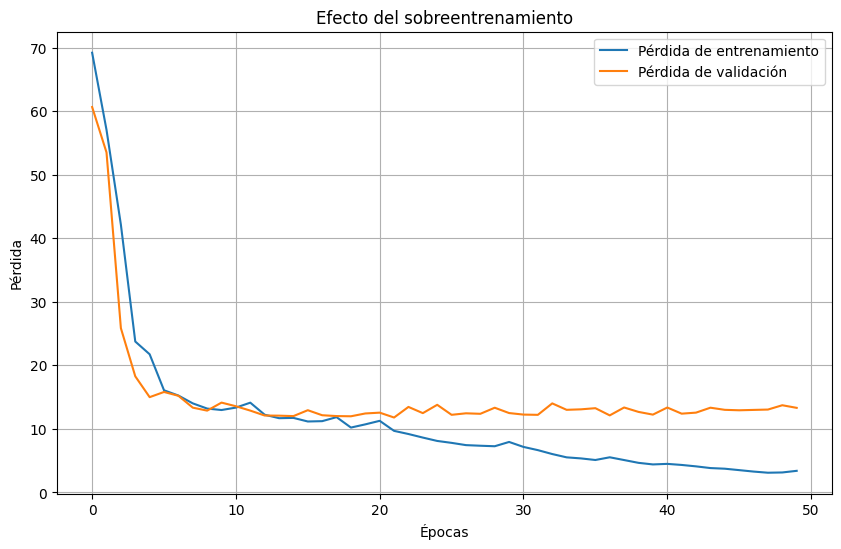

In [4]:
plt.figure(figsize=(10, 6))
plt.plot(history_CNN.history['loss'], label='Pérdida de entrenamiento')
plt.plot(history_CNN.history['val_loss'], label='Pérdida de validación')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.title('Efecto del sobreentrenamiento')
plt.legend()
plt.grid(True)
plt.show()


**E6:** Visualiza algunos ejemplos de imágenes restauradas (procesadas por la red) comparadas con las imágenes de partida (transformadas por el microscopio) y las imágenes sin distorsiones (originales). ¿Se consigue eliminar el ruido? ¿Se consigue restaurar perfectamente la estructura de la molécula original?

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 14.6930 - mae: 1.0538
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 161ms/step
Mean Squared Error: 1.0538


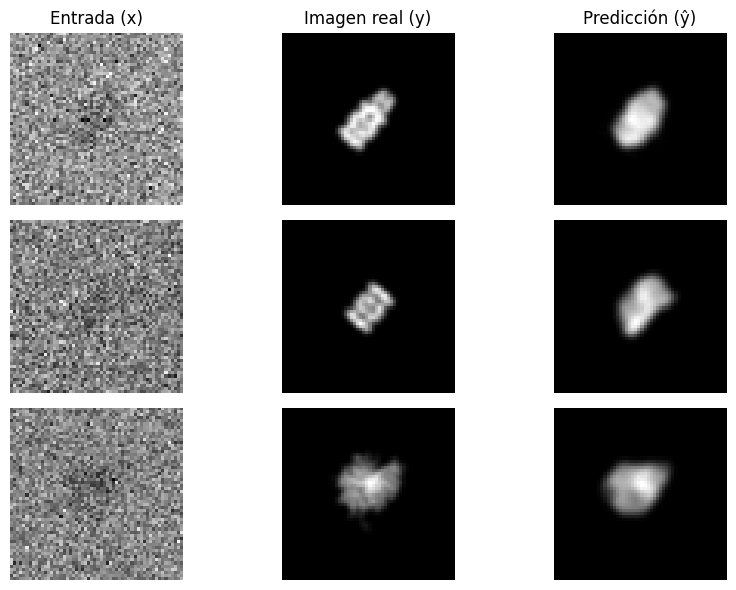

In [5]:
loss, mse = modelo.evaluate(x_test, y_test)
y_pred = modelo.predict(x_test)
print(f"Mean Squared Error: {mse:.4f}")


fig, axes = plt.subplots(3, 3, figsize=(9, 6))

col_titles = ["Entrada (x)", "Imagen real (y)", "Predicción (ŷ)"]
for j, t in enumerate(col_titles):
    axes[0, j].set_title(t, fontsize=12)

axes[0][0].imshow(x_test[0], cmap = 'gray')
axes[0][1].imshow(y_test[0], cmap = 'gray')
axes[0][2].imshow(y_pred[0], cmap = 'gray')
axes[0][0].axis('off')
axes[0][1].axis('off')
axes[0][2].axis('off')

axes[1][0].imshow(x_test[1], cmap = 'gray')
axes[1][1].imshow(y_test[1], cmap = 'gray')
axes[1][2].imshow(y_pred[1], cmap = 'gray')
axes[1][0].axis('off')
axes[1][1].axis('off')
axes[1][2].axis('off')

axes[2][0].imshow(x_test[2], cmap = 'gray')
axes[2][1].imshow(y_test[2], cmap = 'gray')
axes[2][2].imshow(y_pred[2], cmap = 'gray')
axes[2][0].axis('off')
axes[2][1].axis('off')
axes[2][2].axis('off')

plt.tight_layout()

El ruido se consige eliminar al completo pero la proteína no es exactamente la misma, aunque se aproxima bastante el contorno exterior. Por lo tanto, el rendimiento del modelo no es malo pero no es capaz de reconstruir con precisión las moléculas.

**E7:** Repite los ejercicios E5 e E6 pero añadiendo unos mecanismos de parada temprana para evitar la aparición de sobreajuste. ¿Cuánto dura ahora el entrenamiento? ¿Se ha conseguido un mejor resultado? ¿Por qué?

In [6]:
from tensorflow.keras.layers import Input, concatenate, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt


def unet_model(input_shape = (56,56,1)):
	input = Input(shape=(56,56,1))
	
	# Primer bloque convolucional
	x = Conv2D(32, (3,3), activation='relu', padding='same')(input) # 3x3 es el tamaño del filtro que se aplica
	high = Conv2D(32, (3,3), activation='relu', padding='same')(x) # padding = same significa que la entrada tiene el mismo tamaño que la salida
	
	x = MaxPooling2D((2,2), strides = None)(high)

	# Segundo bloque convolucional
	x = Conv2D(48, (3,3), activation='relu', padding='same')(x)
	low = Conv2D(48, (3,3), activation='relu', padding='same')(x)
	
	x = MaxPooling2D((2,2), strides = None)(low)

	# Tercer bloque convolucional
	x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
	x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
	x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
	x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
	
	x = UpSampling2D((2,2), data_format = 'channels_last')(x)
	x = Conv2D(64, (2,2), padding = 'same', activation = 'relu')(x)

	concat = concatenate([x, low])

	# Cuarto bloque convolucional 
	x = Conv2D(48, (3,3), activation='relu', padding='same')(concat)
	x = Conv2D(48, (3,3), activation='relu', padding='same')(x)

	x = UpSampling2D((2,2), data_format = 'channels_last')(x)
	x = Conv2D(48, (2,2), padding = 'same', activation = 'relu')(x)

	concat = concatenate([x, high])

	x = Conv2D(32, (3,3), activation='relu', padding='same')(concat) # 3x3 es el tamaño del filtro que se aplica
	x = Conv2D(32, (3,3), activation='relu', padding='same')(x)

	# Reconstrucción
	output = Conv2D(1, (1,1), padding='same', activation='linear')(x)

	model = Model(input,output)

	return model

modelo = unet_model()

modelo.compile(optimizer='adam', loss='mse', metrics=['mae']) # Sparse porque tenemos 5 clases

In [7]:
from keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_mae',   
    patience=5,
    min_delta=1e-3,
    restore_best_weights=True,
    mode='min',
    verbose=1
)


history_CNN = modelo.fit(x_train, y_train,
    validation_split=0.2,
    batch_size=16,
    epochs=50,
    callbacks = [early_stopping])

Epoch 1/50


20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 120ms/step - loss: 55.9725 - mae: 3.1506 - val_loss: 46.7491 - val_mae: 2.9103
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 110ms/step - loss: 39.8730 - mae: 2.7458 - val_loss: 36.3078 - val_mae: 2.5188
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - loss: 31.8619 - mae: 2.1859 - val_loss: 27.0265 - val_mae: 1.7752
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - loss: 28.3190 - mae: 2.0573 - val_loss: 21.3287 - val_mae: 2.1643
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 103ms/step - loss: 22.9286 - mae: 1.7896 - val_loss: 16.9930 - val_mae: 1.6465
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - loss: 18.0266 - mae: 1.4815 - val_loss: 15.7077 - val_mae: 1.3994
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - loss: 14.6311 - mae: 1.2228 - val_loss: 12.8407 - val_mae: 1.1526
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - loss: 12.9088 - mae: 1.1762 - val_loss: 13.3660 - val_mae: 1.0703
Epoch 9/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 97ms/step - lo

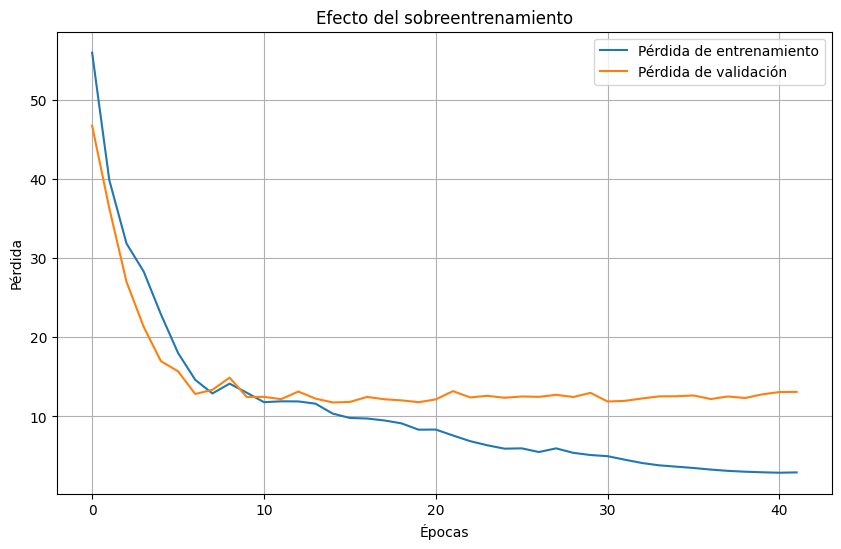

In [8]:
plt.figure(figsize=(10, 6))
plt.plot(history_CNN.history['loss'], label='Pérdida de entrenamiento')
plt.plot(history_CNN.history['val_loss'], label='Pérdida de validación')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.title('Efecto del sobreentrenamiento')
plt.legend()
plt.grid(True)
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 14.5479 - mae: 1.0504
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step
Mean Squared Error: 1.0504


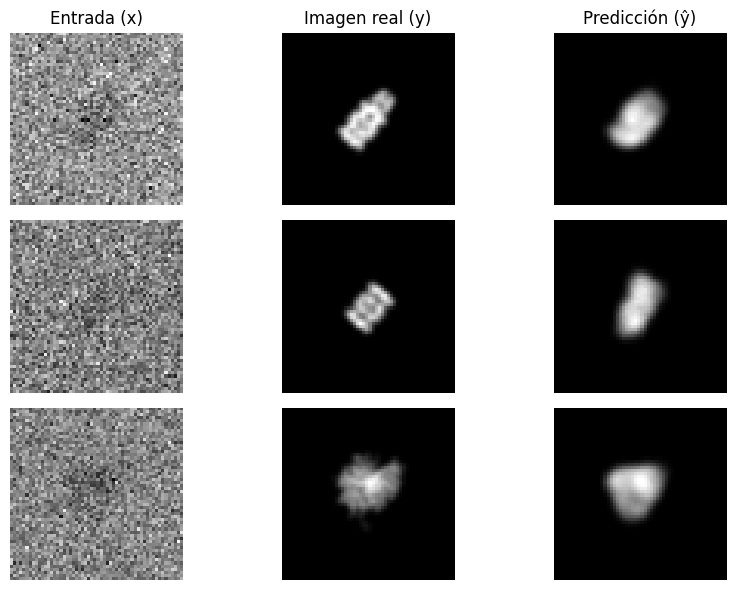

In [9]:
loss, mse = modelo.evaluate(x_test, y_test)
y_pred = modelo.predict(x_test)
print(f"Mean Squared Error: {mse:.4f}")


fig, axes = plt.subplots(3, 3, figsize=(9, 6))

col_titles = ["Entrada (x)", "Imagen real (y)", "Predicción (ŷ)"]
for j, t in enumerate(col_titles):
    axes[0, j].set_title(t, fontsize=12)

axes[0][0].imshow(x_test[0], cmap = 'gray')
axes[0][1].imshow(y_test[0], cmap = 'gray')
axes[0][2].imshow(y_pred[0], cmap = 'gray')
axes[0][0].axis('off')
axes[0][1].axis('off')
axes[0][2].axis('off')

axes[1][0].imshow(x_test[1], cmap = 'gray')
axes[1][1].imshow(y_test[1], cmap = 'gray')
axes[1][2].imshow(y_pred[1], cmap = 'gray')
axes[1][0].axis('off')
axes[1][1].axis('off')
axes[1][2].axis('off')

axes[2][0].imshow(x_test[2], cmap = 'gray')
axes[2][1].imshow(y_test[2], cmap = 'gray')
axes[2][2].imshow(y_pred[2], cmap = 'gray')
axes[2][0].axis('off')
axes[2][1].axis('off')
axes[2][2].axis('off')

plt.tight_layout()

Se ha obtenido un MAE muy cercano al rendimiento del modelo sin parada anticipada. El entrenamiento de este modelo ha durado 25 épocas, la mitad de las épocas del primero y se ha obtenido un rendimiento similar. El hecho de incluir la parada anticipada, ha hecho que el modelo tarde la mitad de tiempo ahorrando la mitad de cómputo y obteniendo MAE casi igual. Luego la parada anticipada ha sido beneficiosa para este caso. Se han establecido los siguientes parámetros:
- Paciencia: 5 épocas
- Delta: 10^-3